## Data Exploration & Preprocessing

###  Load & Inspect the Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('../data/maternal_health.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1014, 7)

First 5 rows:


,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [17]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1014 non-null   int64  
 1   SystolicBP     1014 non-null   int64  
 2   DiastolicBP    1014 non-null   int64  
 3   Blood glucose  1014 non-null   float64
 4   BodyTemp       1014 non-null   float64
 5   HeartRate      1014 non-null   int64  
 6   RiskLevel      1014 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 55.6 KB


In [18]:
# Statistical summary
df.describe().round(2)

,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,RiskLevel
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30,0.87
std,13.47,18.4,13.89,3.29,1.37,8.09,0.81
min,10.00,70.0,49.00,6.00,98.00,7.00,0.00
25%,19.00,100.0,65.00,6.90,98.00,70.00,0.00
50%,26.00,120.0,80.00,7.50,98.00,76.00,1.00
75%,39.00,120.0,90.00,8.00,98.00,80.00,2.00
max,70.00,160.0,100.00,19.00,103.00,90.00,2.00


In [19]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Age              0
SystolicBP       0
DiastolicBP      0
Blood glucose    0
BodyTemp         0
HeartRate        0
RiskLevel        0
dtype: int64

Duplicate rows: 562


In [20]:
# Class distribution
print("\nRisk Level Distribution:")
print(df['RiskLevel'].value_counts())
print("\nPercentage:")
print(df['RiskLevel'].value_counts(normalize=True).round(3) * 100)


Risk Level Distribution:
RiskLevel
0    406
1    336
2    272
Name: count, dtype: int64

Percentage:
RiskLevel
0    40.0
1    33.1
2    26.8
Name: proportion, dtype: float64


### Visualise Feature Distributions

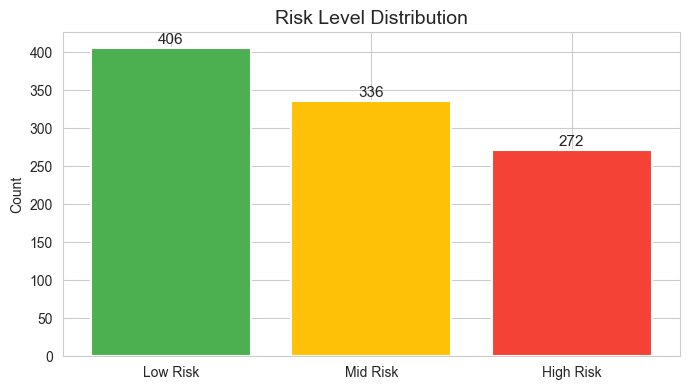

In [23]:
# --- Class distribution bar chart ---
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Low Risk', 'Mid Risk', 'High Risk']
colors = ['#4CAF50', '#FFC107', '#F44336']
counts = df['RiskLevel'].value_counts().sort_index()

bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontsize=11)

ax.set_title('Risk Level Distribution', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()

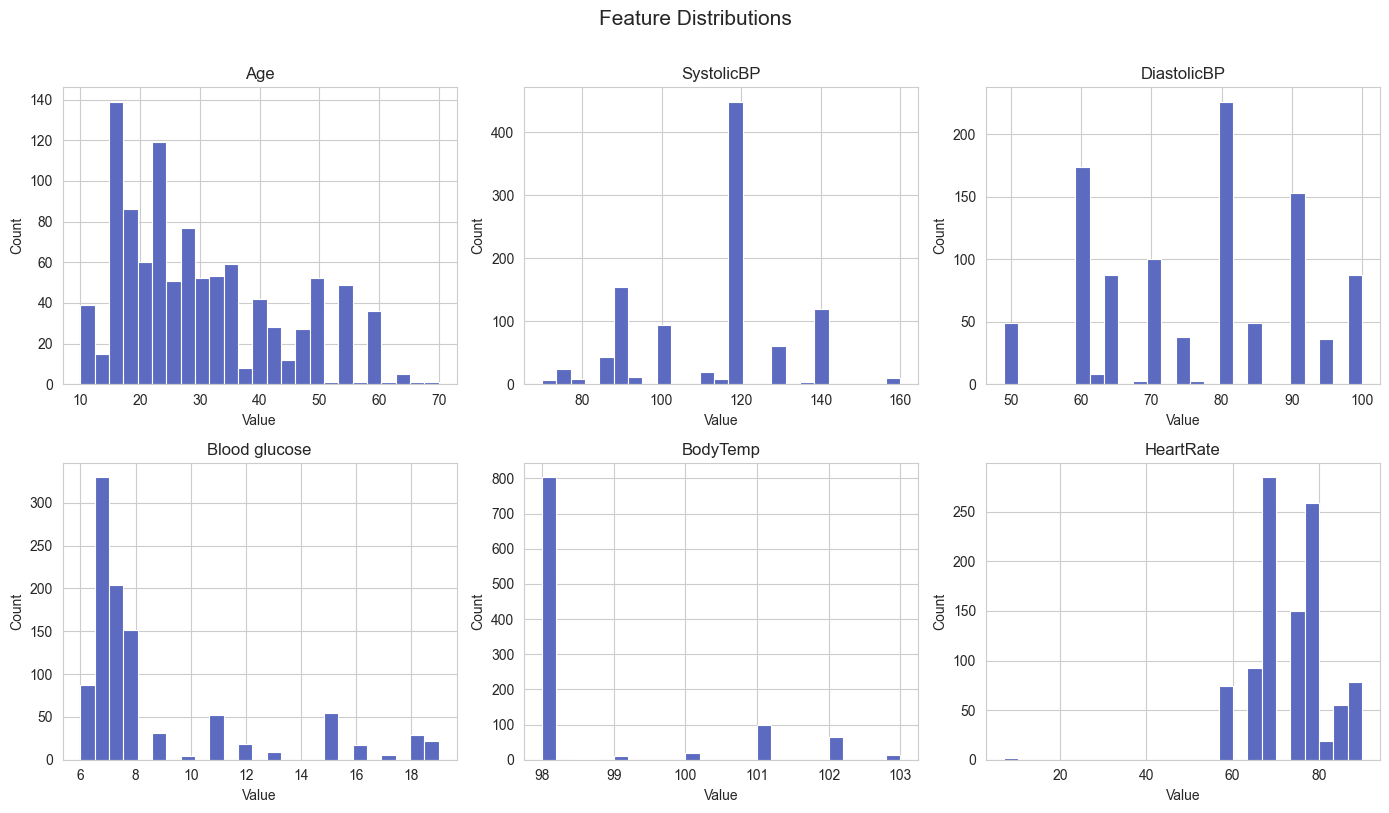

In [24]:
# --- Histograms for all features ---
features = ['Age', 'SystolicBP', 'DiastolicBP', 'Blood glucose', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='#5C6BC0', edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150)
plt.show()

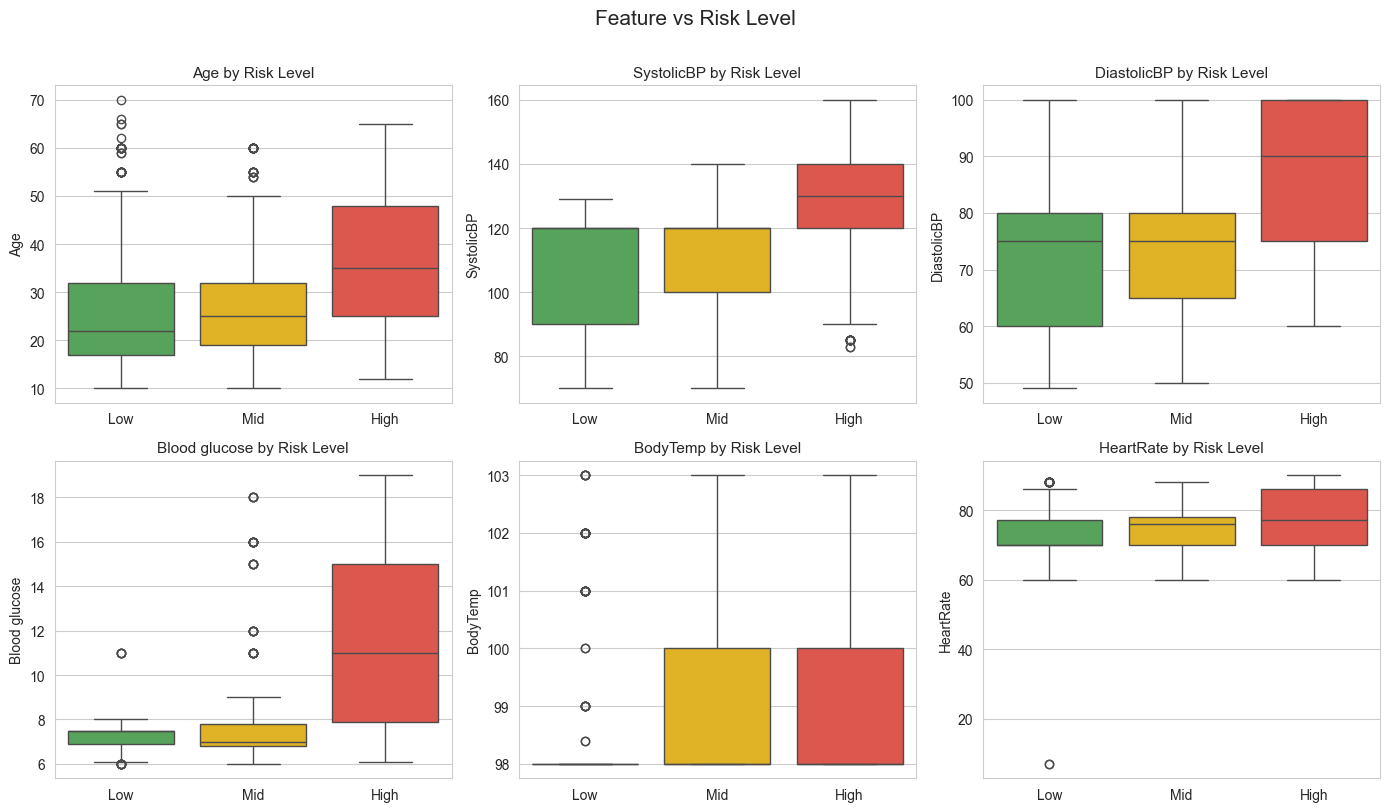

In [25]:
# --- Boxplots by Risk Level ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
risk_labels = {0: 'Low', 1: 'Mid', 2: 'High'}

for i, col in enumerate(features):
    df_plot = df.copy()
    df_plot['Risk'] = df_plot['RiskLevel'].map(risk_labels)
    order = ['Low', 'Mid', 'High']
    palette = {'Low': '#4CAF50', 'Mid': '#FFC107', 'High': '#F44336'}
    sns.boxplot(data=df_plot, x='Risk', y=col, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} by Risk Level', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature vs Risk Level', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../data/boxplots.png', dpi=150)
plt.show()

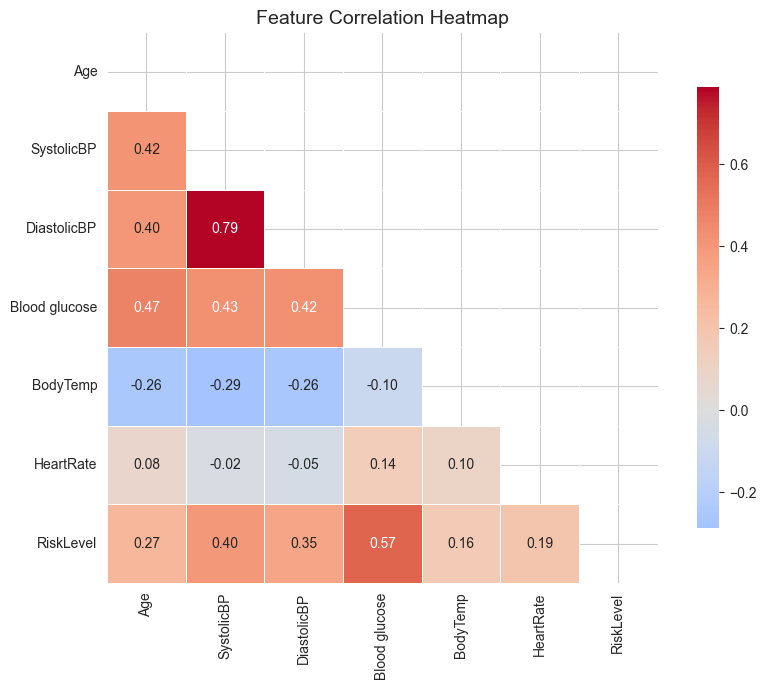

In [26]:
# --- Correlation Heatmap ---
plt.figure(figsize=(9, 7))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

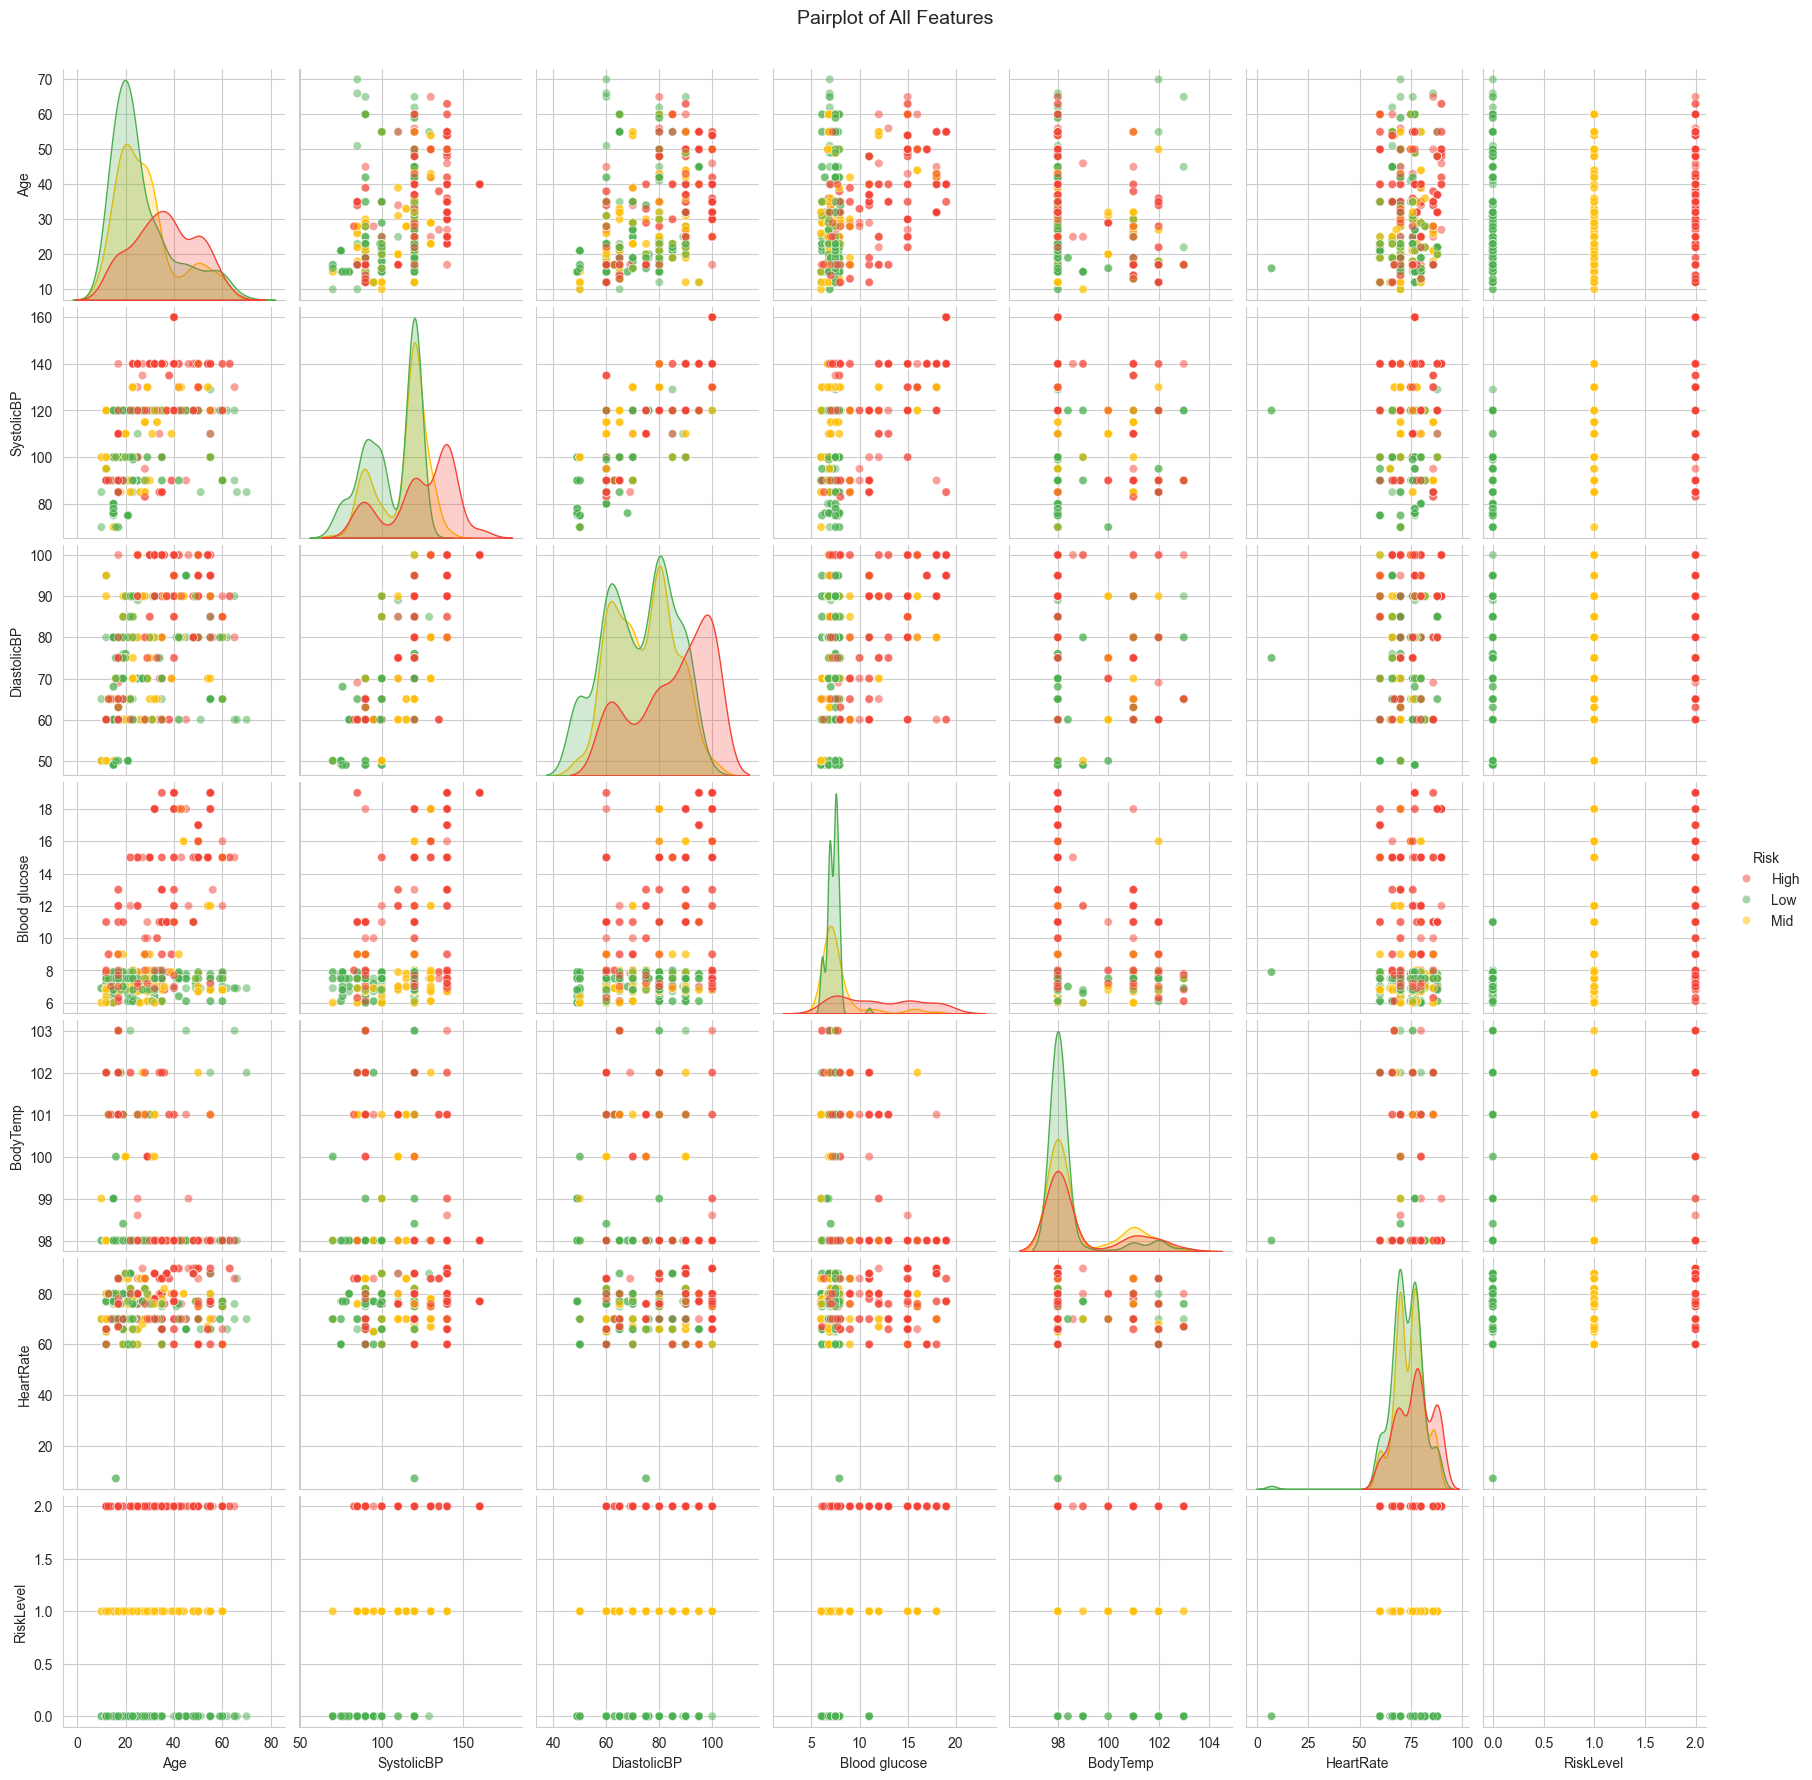

In [27]:
# --- Pairplot (optional but very insightful) ---
df_plot = df.copy()
df_plot['Risk'] = df_plot['RiskLevel'].map({0:'Low', 1:'Mid', 2:'High'})

sns.pairplot(df_plot, hue='Risk',
             palette={'Low':'#4CAF50', 'Mid':'#FFC107', 'High':'#F44336'},
             plot_kws={'alpha': 0.5},
             diag_kind='kde')

plt.suptitle('Pairplot of All Features', y=1.02, fontsize=14)
plt.savefig('../data/pairplot.png', dpi=150)
plt.show()

### Outlier Detection

In [28]:
# --- IQR Outlier Detection ---
print("Outlier counts per feature (IQR method):\n")

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col:20s}: {len(outliers)} outliers  (range: {lower:.1f} – {upper:.1f})")

Outlier counts per feature (IQR method):

  Age                 : 1 outliers  (range: -11.0 – 69.0)
  SystolicBP          : 10 outliers  (range: 70.0 – 150.0)
  DiastolicBP         : 0 outliers  (range: 27.5 – 127.5)
  Blood glucose       : 210 outliers  (range: 5.3 – 9.6)
  BodyTemp            : 210 outliers  (range: 98.0 – 98.0)
  HeartRate           : 2 outliers  (range: 55.0 – 95.0)


In [29]:
# --- Cap outliers using IQR (Winsorization) ---
df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("Outliers capped successfully.")
print("Clean dataset shape:", df_clean.shape)

Outliers capped successfully.
Clean dataset shape: (1014, 7)


###  Feature Scaling & Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_clean.drop('RiskLevel', axis=1)
y = df_clean['RiskLevel']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Scaled feature sample:")
print(X_scaled_df.head(3).round(3))

Scaled feature sample:
     Age  SystolicBP  DiastolicBP  Blood glucose  BodyTemp  HeartRate
0 -0.362       0.930        0.255          1.700       0.0      1.535
1  0.381       1.481        0.976          1.700       0.0     -0.582
2 -0.065      -1.271       -0.465          0.251       0.0      0.741


In [31]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← important for imbalanced classes
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Testing set:   {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(pd.Series(y_train).value_counts().sort_index()
      .rename({0:'Low', 1:'Mid', 2:'High'}))

Training set:  811 rows
Testing set:   203 rows

Class balance in training set:
RiskLevel
Low     325
Mid     269
High    217
Name: count, dtype: int64


In [33]:
# Save the cleaned data and scaler 
import joblib

df_clean.to_csv('../data/maternal_health_clean.csv', index=False)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump((X_train, X_test, y_train, y_test), '../models/train_test_split.pkl')

print("Saved:")
print("  ✓ data/maternal_health_clean.csv")
print("  ✓ models/scaler.pkl")
print("  ✓ models/train_test_split.pkl")

Saved:
  ✓ data/maternal_health_clean.csv
  ✓ models/scaler.pkl
  ✓ models/train_test_split.pkl
